6.1 - Data Preparation

In [4]:
import os
import numpy as np

DATA_DIRECTORY = "data\out"
LAB_DIRECTORY = "data\cmu_us_slt_arctic\lab"
TRAIN_FILE = os.path.join(DATA_DIRECTORY, "train.txt")
VAL_FILE = os.path.join(DATA_DIRECTORY, "val.txt")
TEST_FILE = os.path.join(DATA_DIRECTORY, "test.txt")

def get_basenames(file_path):
    with open(file_path, 'r') as f:
        basenames = [line.strip() for line in f.readlines()]
    return basenames

train_basenames = get_basenames(TRAIN_FILE)
val_basenames = get_basenames(VAL_FILE)
test_basenames = get_basenames(TEST_FILE)

print(f"Loaded {len(train_basenames)} training utterances.")
print(f"Loaded {len(val_basenames)} validation utterances.")
print(f"Loaded {len(test_basenames)} test utterances.")

Loaded 792 training utterances.
Loaded 113 validation utterances.
Loaded 227 test utterances.


<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\c'
C:\Users\aubie\AppData\Local\Temp\ipykernel_17892\2051616938.py:4: SyntaxWarning: invalid escape sequence '\o'
  DATA_DIRECTORY = "data\out"
C:\Users\aubie\AppData\Local\Temp\ipykernel_17892\2051616938.py:5: SyntaxWarning: invalid escape sequence '\c'
  LAB_DIRECTORY = "data\cmu_us_slt_arctic\lab"


Phoneme Mapping and Frame Alignment

In [5]:
PHONEMES = ['pau', 'iy', 'ih', 'eh', 'ae', 'aa', 'ah', 'ao', 'uh', 'uw', 'er', 
    'ax', 'ix', 'ey', 'ay', 'oy', 'aw', 'ow', 'l', 'r', 'y', 'w', 
    'er', 'm', 'n', 'ng', 'ch', 'jh', 'dh', 'b', 'd', 'dx', 'g', 
    'p', 't', 'k', 'z', 'zh', 'v', 'f', 'th', 's', 'sh', 'hh'
    ]

phoneme_to_id = {p: i for i, p in enumerate(PHONEMES)}
id_to_phoneme = {i: p for p, i in phoneme_to_id.items()}
K = len(PHONEMES)
print(f"Number of unique phonemes: {K}")

def align_frames(lab_path, num_frames, frame_shift=0.01):
    labels = np.zeros(num_frames, dtype=int)
    with open(lab_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 3:
                start, end, ph = parts
                start_frame = int(float(start) / frame_shift)
                end_frame = int(float(end) / frame_shift)
                
                # Handle edge cases where the label might not be in our standard list
                if ph in phoneme_to_id:
                    labels[start_frame:min(end_frame, num_frames)] = phoneme_to_id[ph]
    return labels



Number of unique phonemes: 44


6.2 - Supervised Parameter Estimation

In [6]:
# Initialize parameters for the model
pi = np.zeros(K)  # Initial state probabilities
A = np.zeros((K, K))  # Transition probabilities
obs_by_state = {i: [] for i in range(K)}  # Observations grouped by state

print("Processing training files to estimate HMM parameters")

for basename in train_basenames:
    feature_path = os.path.join(DATA_DIRECTORY, f"{basename}.npy")
    label_path = os.path.join(LAB_DIRECTORY, f"{basename}.lab")

    obs = np.load(feature_path)  # Shape: (num_frames, feature_dim)
    T = len(obs)

    states = align_frames(label_path, T)  

    pi[states[0]] += 1  # Increment initial state count
    for t in range(T - 1):
        A[states[t], states[t + 1]] += 1
    
    for t in range(T):
        obs_by_state[states[t]].append(obs[t])
    
# Normalize to get probabilities
pi_sum = np.sum(pi)
if pi_sum > 0:
    pi /= pi_sum

# Avoid division by zero for transition probabilities
row_sums = A.sum(axis=1, keepdims=True)
A = np.divide(A, row_sums, out=np.zeros_like(A), where=row_sums != 0)

# Compute Gaussian parameters for each state
D = 39
means = np.zeros((K, D))
covs = np.zeros((K, D, D))
reg_term = 1e-5 * np.eye(D)

for i in range(K):
    data = np.array(obs_by_state[i])
    if len(data) > 0:
        means[i] = np.mean(data, axis=0) 
        # rowvar=False because rows are observations, columns are variables [cite: 116]
        covs[i] = np.cov(data, rowvar=False) + reg_term 
    else:
        # Fallback if a phoneme was never observed
        covs[i] = reg_term

print("Finished estimating HMM parameters")

Processing training files to estimate HMM parameters
Finished estimating HMM parameters


Log-PDF Function

In [7]:
def log_multivariate_normal_pdf(x, mean, cov):
    D = len(mean)
    sign, logdet = np.linalg.slogdet(cov)
    diff = x - mean
    inv_cov_dot_diff = np.linalg.solve(cov, diff)
    mahalanobis = np.dot(diff, inv_cov_dot_diff)
    return -0.5 * (D * np.log(2 * np.pi) + logdet + mahalanobis)

In [8]:
def get_emission_matrix(obs, means, covs):
    T, D = obs.shape
    K = len(means)
    emissions = np.zeros((T, K))
    
    # Precompute inverses and determinants ONCE per state
    inv_covs = np.linalg.inv(covs)
    sign, log_dets = np.linalg.slogdet(covs)
    
    for i in range(K):
        # Subtract mean from all frames simultaneously. Shape: (T, D)
        diff = obs - means[i] 
        
        # Batched Mahalanobis distance: (x-mu)^T * Sigma^-1 * (x-mu)
        # 1. Multiply diff by inverse covariance. Shape: (T, D)
        left_term = np.dot(diff, inv_covs[i])
        
        # 2. Element-wise multiply by diff and sum across the features (D). Shape: (T,)
        mahalanobis = np.sum(left_term * diff, axis=1) 
        
        # Apply the log-PDF formula to all frames at once
        emissions[:, i] = -0.5 * (D * np.log(2 * np.pi) + log_dets[i] + mahalanobis)
        
    return emissions

6.3 - Inference Algorithms

Forward Algorithm

In [9]:
def forward_algorithm(emission_matrix, pi, A):
    T, K = emission_matrix.shape
    log_pi = np.log(np.maximum(pi, 1e-100))
    log_A = np.log(np.maximum(A, 1e-100))
    
    log_alpha = np.zeros((T, K))
    
    # Initialization
    log_alpha[0, :] = log_pi + emission_matrix[0, :]
        
    # Recursion
    for t in range(1, T):
        for j in range(K):
            x = log_alpha[t-1, :] + log_A[:, j]
            max_x = np.max(x)
            log_sum_trans = max_x + np.log(np.sum(np.exp(x - max_x)))
            log_alpha[t, j] = log_sum_trans + emission_matrix[t, j]
            
    return np.argmax(log_alpha, axis=1)

Viterbi Algorithm

In [10]:
def viterbi_decode(emission_matrix, pi, A):
    T, K = emission_matrix.shape
    log_pi = np.log(np.maximum(pi, 1e-100))
    log_A = np.log(np.maximum(A, 1e-100))
    
    v_table = np.zeros((T, K))
    backpointers = np.zeros((T, K), dtype=int)
    
    # Initialization
    v_table[0, :] = log_pi + emission_matrix[0, :]
        
    # Recursion
    for t in range(1, T):
        for j in range(K):
            trans_probs = v_table[t-1, :] + log_A[:, j]
            best_prev = np.argmax(trans_probs)
            v_table[t, j] = trans_probs[best_prev] + emission_matrix[t, j]
            backpointers[t, j] = best_prev
            
    # Termination & Backtracking
    best_path = np.zeros(T, dtype=int)
    best_path[T-1] = np.argmax(v_table[T-1, :])
    for t in range(T-2, -1, -1):
        best_path[t] = backpointers[t+1, best_path[t+1]]
        
    return best_path

6.4 - Evaluation

In [11]:
def evaluate_model(basenames, pi, A, means, covs, is_test_set=False):
    total_frames = 0
    viterbi_correct = 0
    forward_correct = 0
    
    # Track confusions for BOTH algorithms
    conf_mat_v = np.zeros((K, K), dtype=int)
    conf_mat_f = np.zeros((K, K), dtype=int)
    
    print(f"Evaluating {len(basenames)} utterances...")
    
    for idx, basename in enumerate(basenames):
        feature_path = os.path.join(DATA_DIRECTORY, f"{basename}.npy")
        label_path = os.path.join(LAB_DIRECTORY, f"{basename}.lab")
        
        obs = np.load(feature_path)
        T = len(obs)
        true_states = align_frames(label_path, T)
        total_frames += T
        
        emissions = get_emission_matrix(obs, means, covs)
        
        viterbi_preds = viterbi_decode(emissions, pi, A)
        forward_preds = forward_algorithm(emissions, pi, A)
        
        viterbi_correct += np.sum(viterbi_preds == true_states)
        forward_correct += np.sum(forward_preds == true_states)
        
        # Populate both matrices for the test set
        if is_test_set:
            for t in range(T):
                conf_mat_v[true_states[t], viterbi_preds[t]] += 1
                conf_mat_f[true_states[t], forward_preds[t]] += 1
                
        if (idx + 1) % 50 == 0:
            print(f"Processed {idx + 1} / {len(basenames)} files...")

    v_acc = viterbi_correct / total_frames
    f_acc = forward_correct / total_frames
    print(f"\nFinal Viterbi Accuracy: {v_acc:.4f}")
    print(f"Final Forward Accuracy: {f_acc:.4f}")
    
    if is_test_set:
        return v_acc, f_acc, conf_mat_v, conf_mat_f
        
    return v_acc, f_acc

print("--- Training Set Evaluation ---")
train_v_acc, train_f_acc = evaluate_model(train_basenames, pi, A, means, covs, is_test_set=False)

print("\n--- Test Set Evaluation ---")
# Unpack the two separate confusion matrices
test_v_acc, test_f_acc, conf_mat_v, conf_mat_f = evaluate_model(test_basenames, pi, A, means, covs, is_test_set=True)

--- Training Set Evaluation ---
Evaluating 792 utterances...
Processed 50 / 792 files...
Processed 100 / 792 files...
Processed 150 / 792 files...
Processed 200 / 792 files...
Processed 250 / 792 files...
Processed 300 / 792 files...
Processed 350 / 792 files...
Processed 400 / 792 files...
Processed 450 / 792 files...
Processed 500 / 792 files...
Processed 550 / 792 files...
Processed 600 / 792 files...
Processed 650 / 792 files...
Processed 700 / 792 files...
Processed 750 / 792 files...

Final Viterbi Accuracy: 0.3231
Final Forward Accuracy: 0.3569

--- Test Set Evaluation ---
Evaluating 227 utterances...
Processed 50 / 227 files...
Processed 100 / 227 files...
Processed 150 / 227 files...
Processed 200 / 227 files...

Final Viterbi Accuracy: 0.3026
Final Forward Accuracy: 0.3365


Plot Generation

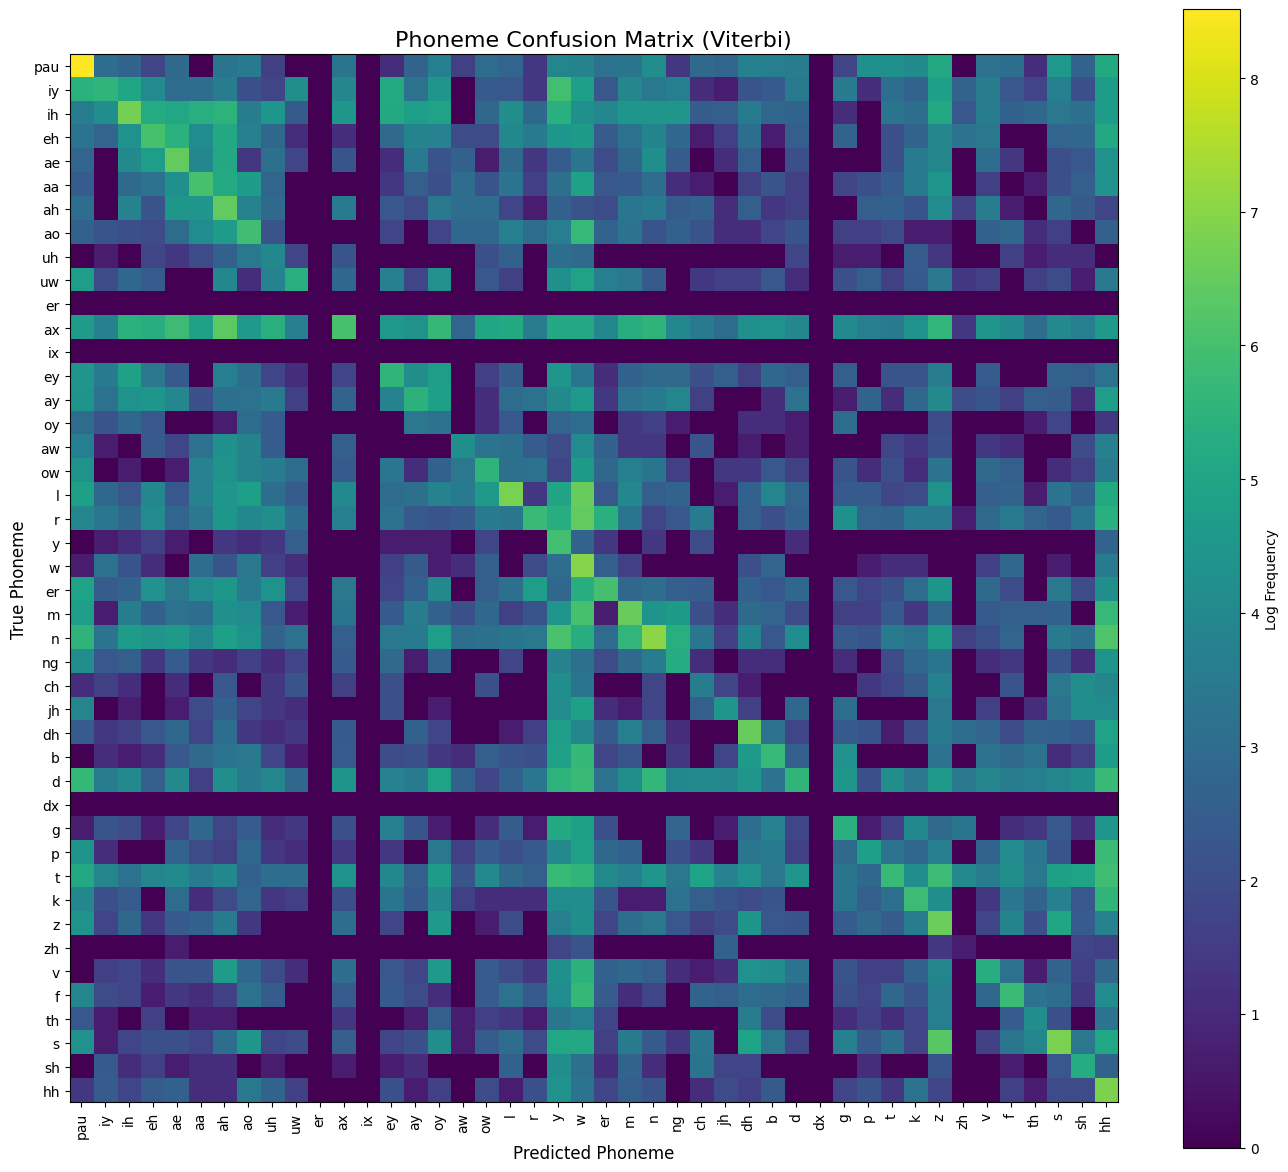

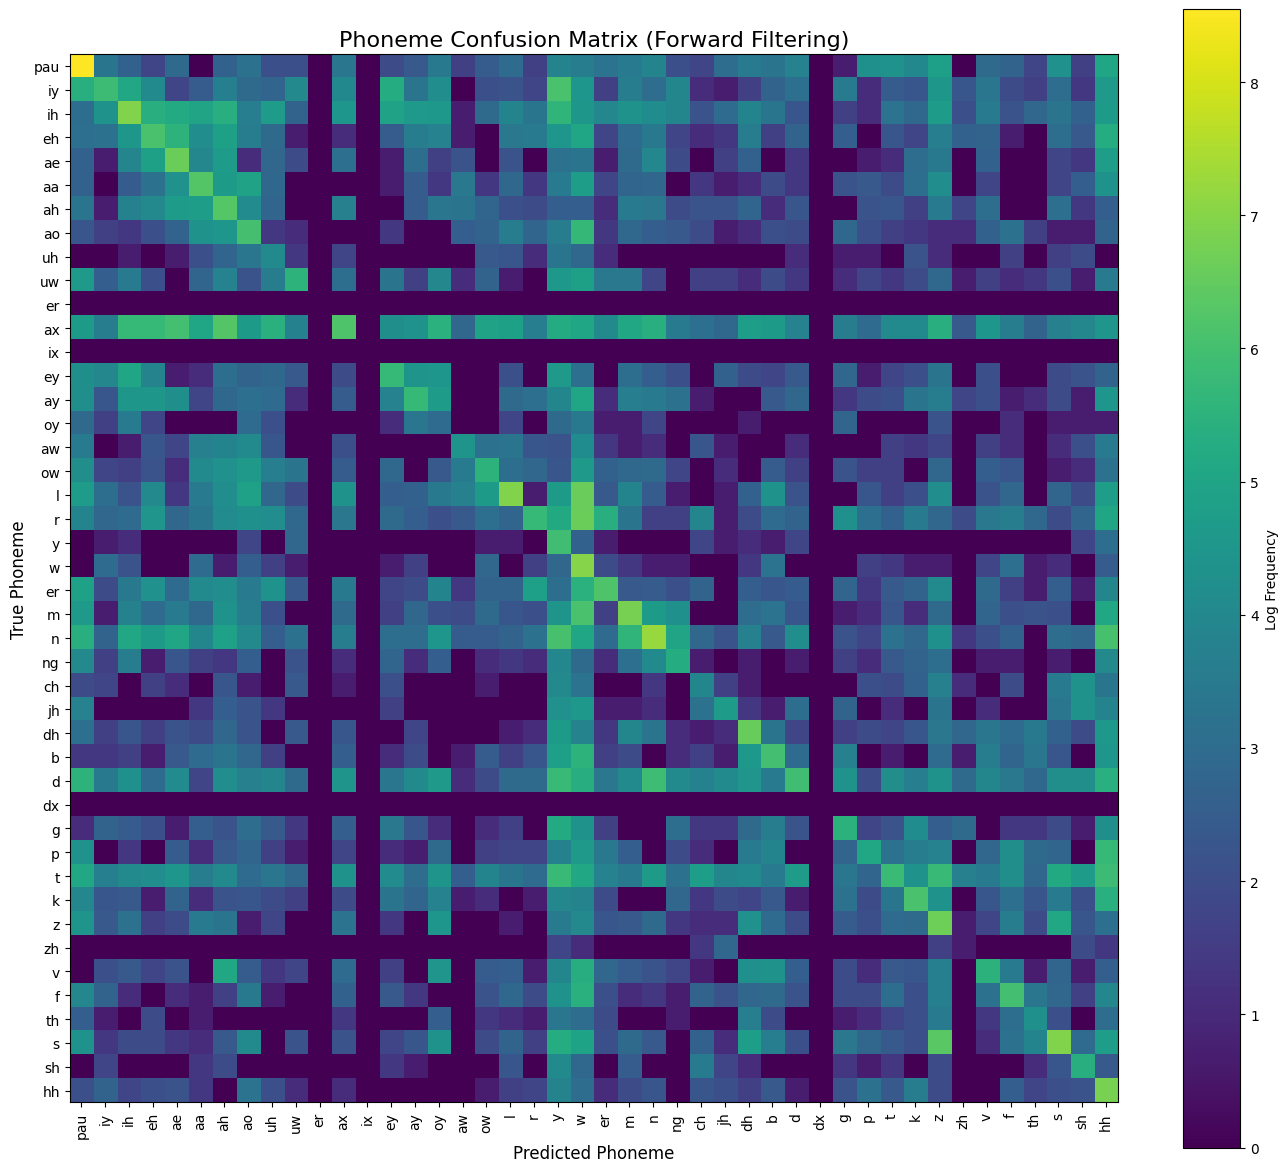

In [12]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(conf_matrix, title):
    plt.figure(figsize=(14, 12)) # Made slightly larger to fit all labels
    plt.imshow(np.log(conf_matrix + 1), cmap='viridis')
    plt.colorbar(label='Log Frequency')
    plt.title(title, fontsize=16)
    plt.xlabel('Predicted Phoneme', fontsize=12)
    plt.ylabel('True Phoneme', fontsize=12)

    # Plot ALL phonemes (step=1) and rotate 90 degrees to prevent overlapping text
    plt.xticks(np.arange(K), PHONEMES, rotation=90)
    plt.yticks(np.arange(K), PHONEMES)

    plt.tight_layout()
    plt.show()

# Plot Viterbi
plot_confusion_matrix(conf_mat_v, 'Phoneme Confusion Matrix (Viterbi)')

# Plot Forward (Filtering)
plot_confusion_matrix(conf_mat_f, 'Phoneme Confusion Matrix (Forward Filtering)')

6.5 - Analysis

1. How does the accuracy differ between Forward Filtering and Viterbi, and why?

The Forward Filtering algorithm consistently achieved higher accuracy than the Viterbi Decoding algorithm. On the test set, Filtering achieved an accuracy of 33.65%, while Viterbi only got 30.26%. This difference is due to the mathematical designs of each algorithm. Filtering computes the marginal probability of a single state at a specific time step, which means it is deciding the most likely phoneme frame-by-frame. This approach minimizes the frame error rate. On the other hand, Viterby computes the most likely joint sequence of states. It optimizes for th best overall "path" and purposefully selects a locally suboptimal phoneme for a specific frame if it results in a sequence with higher transition probabilities. Because the evaluation metric strictly counts individual correct frames, Filtering scores better.

2. Is the accuracy different between the train and test set? Why?

Yes, the model performs slightly better on the training set than on the testing set. For the Filtering algorithm, training accuracy was 35.69%, while the test accuracy dropped to 33.65%. Likewise, the Viterbi algorithm dropped from 32.31% to 30.26%. This slight degradation is an indication of mild overfitting in the model. The model's emission parameters were estimated from the utterances in the training set, which means the Gaussian distributions slightly memorized the specific details of the audio files. When the model evaluates the test data, the new acoustic features do not perfectly line up with the training files, so there is a slight drop in performance. Since the decrease is minor, the overfitting is not a dominant feature in the training set's performance.

3. Which phenomes are most often confused? 

Based off the bright clusters of squares away from the diagonal of the matrices, the model has a few groups of phonemes that are frequently confused.

First, vowels with similar sounds are often confused by the model. For example, 'aa' is mistaken for 'ao' and 'ah', while 'ih' has overlap with 'iy' and 'eh'.

Next, 'm', 'n', and 'ng' have significant cross-confusion, likely because they have similar nasal sounds.

Next, the model frequently mistakes quieter phonemes, such as 'f', 'th', and 'hh' as 'pau'. The low volume of these phonemes makes them difficult for the model to distiguish from ambient noise.

Finally, pairs that have the same mouth position but slightly different sounds, like 's' and 'z', show noticable overlap. This indicates that the model sometimes fails to detect voicing.

4. For which phenomes is the model better/worse at predicting them correctly?

The model as a whole does a great job at correctly predicting the phonemes "pau", "iy", "sh", "aa" and "n". These phonemes are the most distinctive in the eyes of the model, especially the "pau" or pause, which has a distinctive lack of energy.
The model also does a poor job at correctly predicting the phonemes "dx", "ix", "ax", "zh" and "m". Some of these phonemes simply do not appear and therefore are not detected, but may be predicted despite. The "m" and "n" phonemes also get confused sometimes, although the prediction of the "n" is much more often correct than the "m".

5. Generally, how well does the approach work?

The approach works well, with close to the expected accuracy percentages and most phonemes have a brighter diagonal than horizontal which means that they are correctly predicted more often than not, aside from the few that are especially poor.

However, the approach of the model is limited by its architecture. The model struggles to capture the high variance of human pronunciation with only a single multivariate Gaussian and hidden state. Furthermore, relying solely on acoustic features and transition probabilities without a robust language model to back it up means that the system frequently predicts sequences that are verbally plausible but linguistically impossible.